## 1. Load Segmented Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
df = pd.read_csv("../data/accounts_with_segments.csv")
df.head()
print(df["Segment"].value_counts())

Segment
0    3012
3    2746
2    2139
1    2103
Name: count, dtype: int64


## 2. Compute Core Metrics Per Segment

In [6]:
metrics = df.groupby("Segment").agg(
    Accounts=("Segment", "count"),
    Total_ACV=("ACV", "sum"),
    Churned_Accounts=("Exited", "sum"),
    Churned_ACV=("ACV", lambda x: x[df.loc[x.index, "Exited"] == 1].sum())
).reset_index()

metrics["Accounts_%"] = metrics["Accounts"] / metrics["Accounts"].sum() * 100
metrics["Logo_Churn"] = metrics["Churned_Accounts"] / metrics["Accounts"] * 100
metrics["Revenue_Churn"] = metrics["Churned_ACV"] / metrics["Total_ACV"] * 100
metrics["Proxy_GRR"] = (1 - metrics["Revenue_Churn"] / 100) * 100  # Gross Retention Rate
metrics = metrics.round(1)
metrics


,Segment,Accounts,Total_ACV,Churned_Accounts,Churned_ACV,Accounts_%,Logo_Churn,Revenue_Churn,Proxy_GRR
0,0,3012,368290470.7,467,57826575.1,30.1,15.5,15.7,84.3
1,1,2103,33108442.6,477,16412747.4,21.0,22.7,49.6,50.4
2,2,2139,22543828.7,268,9294092.7,21.4,12.5,41.2,58.8
3,3,2746,340916150.8,825,102054679.5,27.5,30.0,29.9,70.1


## 3. Simulate NRR (Net Revenue Retention)

In [8]:
# Simulate NRR: expansion only for retained Growth accounts (Segment 2) with multi-products
df["Sim_Ending_ACV"] = np.where(
    # Retained AND Growth AND multi-product → +15% expansion
    (df["Exited"] == 0) & (df["Segment"] == 2) & (df["NumOfProducts"] > 2),
    df["ACV"] * 1.15,  # Expansion
    np.where(
        # Any other retained account → keep ACV
        df["Exited"] == 0,
        df["ACV"],
        # Churned → 0 ACV
        0
    )
)

# Compute NRR per segment
nrr_metrics = df.groupby("Segment").agg(
    Accounts=("Segment", "count"),
    Starting_ACV=("ACV", "sum"),
    Ending_ACV=("Sim_Ending_ACV", "sum"),
    Retained_ACV=("Sim_Ending_ACV", lambda x: x[x > 0].sum())
).reset_index()

nrr_metrics["Proxy_NRR"] = (nrr_metrics["Ending_ACV"] / nrr_metrics["Starting_ACV"]) * 100
nrr_metrics = nrr_metrics.round(1)
print(nrr_metrics)


   Segment  Accounts  Starting_ACV   Ending_ACV  Retained_ACV  Proxy_NRR
0        0      3012   368290470.7  310463895.7   310463895.7       84.3
1        1      2103    33108442.6   16695695.2    16695695.2       50.4
2        2      2139    22543828.7   13316490.8    13316490.8       59.1
3        3      2746   340916150.8  238861471.4   238861471.4       70.1


## 4. Visualize 

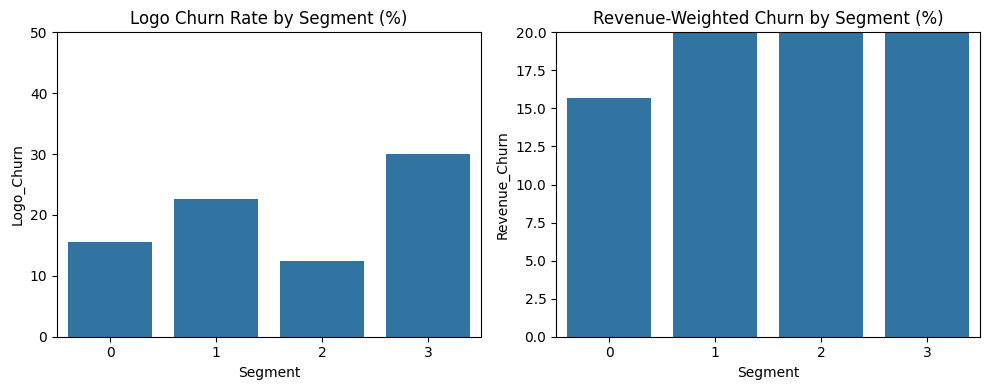

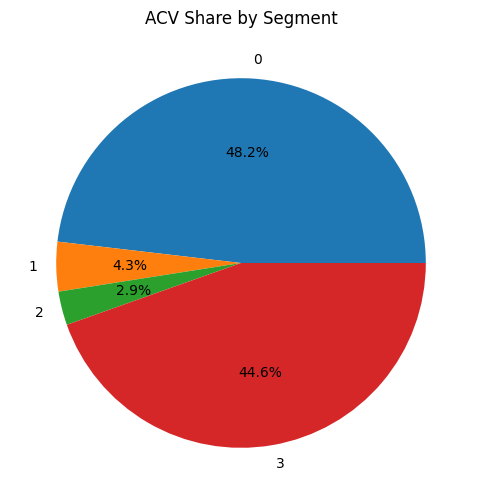

In [9]:
# Churn rate by segment
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(data=metrics, x="Segment", y="Logo_Churn")
plt.title("Logo Churn Rate by Segment (%)")
plt.ylim(0, 50)

plt.subplot(1, 2, 2)
sns.barplot(data=metrics, x="Segment", y="Revenue_Churn")
plt.title("Revenue-Weighted Churn by Segment (%)")
plt.ylim(0, 20)
plt.tight_layout()
plt.savefig("../visuals/churn_by_segment.png", dpi=300, bbox_inches='tight')
plt.show()

# ACV share pie
plt.figure(figsize=(6, 6))
plt.pie(metrics["Total_ACV"], labels=metrics["Segment"], autopct='%1.1f%%')
plt.title("ACV Share by Segment")
plt.savefig("../visuals/acv_share_by_segment.png", dpi=300, bbox_inches='tight')
plt.show()


## 6. Save

In [10]:
df.to_csv("../data/accounts_retention_metrics.csv", index=False)
